<a href="https://colab.research.google.com/github/Sezikeye/Assignment-AI/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [4]:
df = pd.read_csv("50_Startups.csv")
print(df.head())


   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94


In [5]:
print("Shape:", df.shape)


Shape: (50, 5)


In [6]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB
None


In [7]:
print(df.describe())


           R&D Spend  Administration  Marketing Spend         Profit
count      50.000000       50.000000        50.000000      50.000000
mean    73721.615600   121344.639600    211025.097800  112012.639200
std     45902.256482    28017.802755    122290.310726   40306.180338
min         0.000000    51283.140000         0.000000   14681.400000
25%     39936.370000   103730.875000    129300.132500   90138.902500
50%     73051.080000   122699.795000    212716.240000  107978.190000
75%    101602.800000   144842.180000    299469.085000  139765.977500
max    165349.200000   182645.560000    471784.100000  192261.830000


In [8]:
print(df.isnull().sum())


R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64


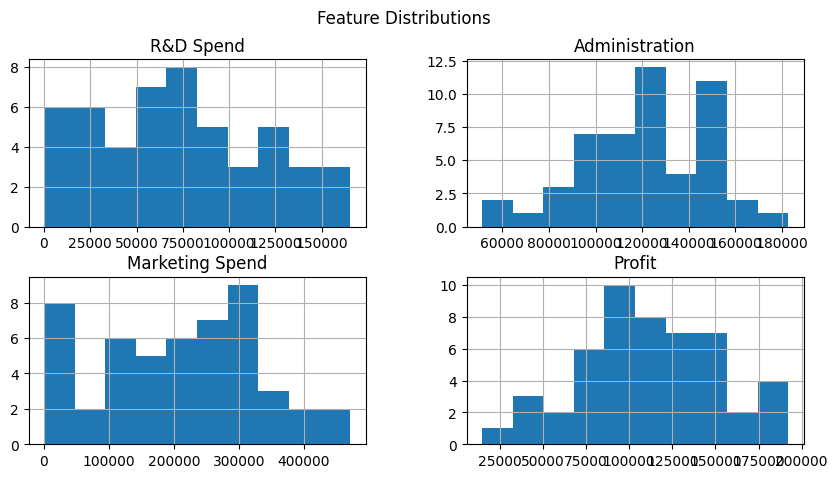

In [13]:
df.hist(figsize=(10, 5))
plt.suptitle("Feature Distributions")
plt.show()


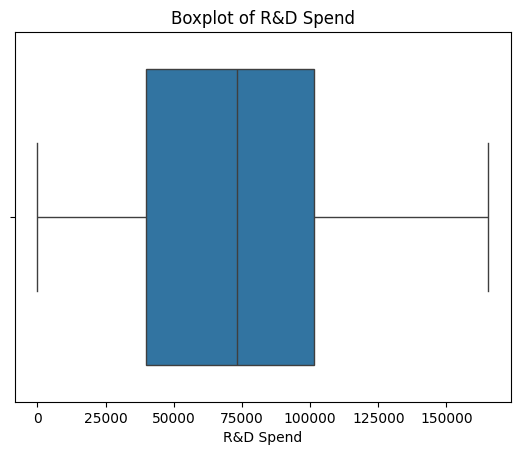

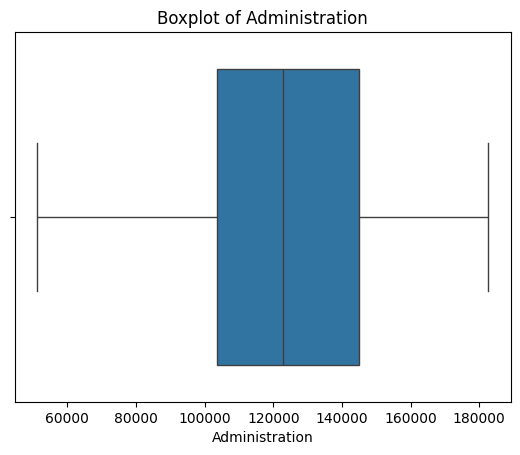

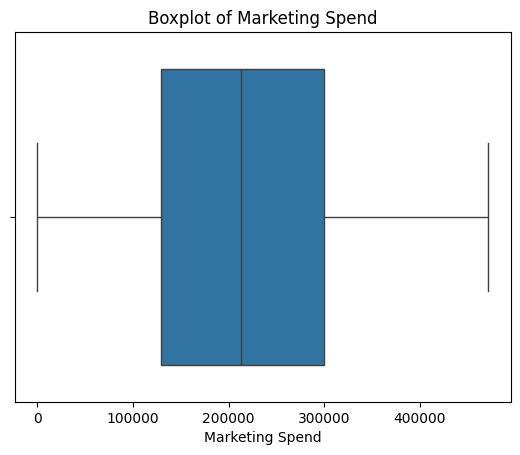

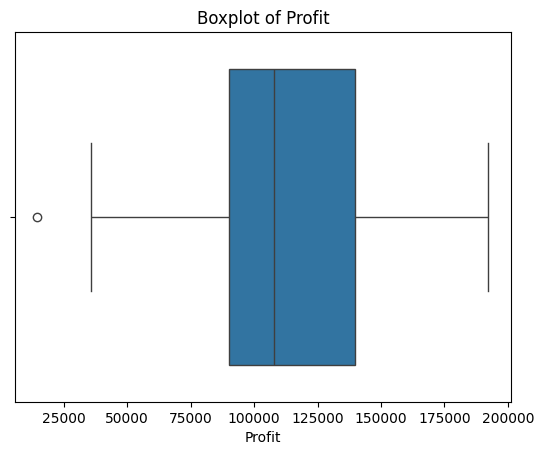

In [14]:
for col in df.select_dtypes(include='number').columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


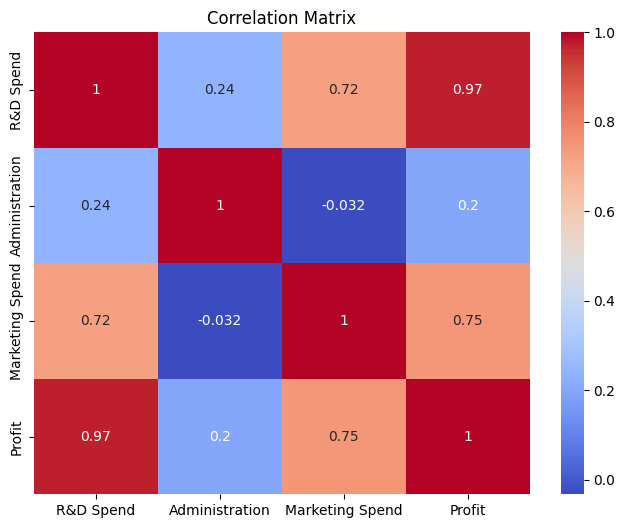

In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [16]:
# Features (inputs)
X = df[['R&D Spend', 'Administration', 'Marketing Spend']]

# Target (output)
y = df['Profit']   # or 'Expenses'

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test data
    random_state=42     # ensures reproducibility
)

In [18]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print(X_train.head())
print(X_test.head())


X_train: (40, 3)
X_test: (10, 3)
y_train: (40,)
y_test: (10,)
    R&D Spend  Administration  Marketing Spend
12   93863.75       127320.38        249839.44
4   142107.34        91391.77        366168.42
37   44069.95        51283.14        197029.42
8   120542.52       148718.95        311613.29
3   144372.41       118671.85        383199.62
    R&D Spend  Administration  Marketing Spend
13   91992.39       135495.07        252664.93
39   38558.51        82982.09        174999.30
30   61994.48       115641.28         91131.24
45    1000.23       124153.04          1903.93
17   94657.16       145077.58        282574.31


In [19]:
# Initialize model
model = LinearRegression()

# Train the model on training data
model.fit(X_train, y_train)

print("Linear Regression model training complete.")


Linear Regression model training complete.


In [20]:
# features importance

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

print(coefficients)
print("\nIntercept:", model.intercept_)

           Feature  Coefficient
0        R&D Spend     0.803779
1   Administration    -0.067929
2  Marketing Spend     0.031242

Intercept: 54071.87574599082


In [21]:
# Model prediction
y_pred = model.predict(X_test)


In [22]:
# Model evaluation
print("Mean Absolute Error:", metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R-squared:", metrics.r2_score(y_test, y_pred))


Mean Absolute Error: 6979.152252370402
Mean Squared Error: 80926321.22295158
Root Mean Squared Error: 8995.905803361415
R-squared: 0.9000653083037321


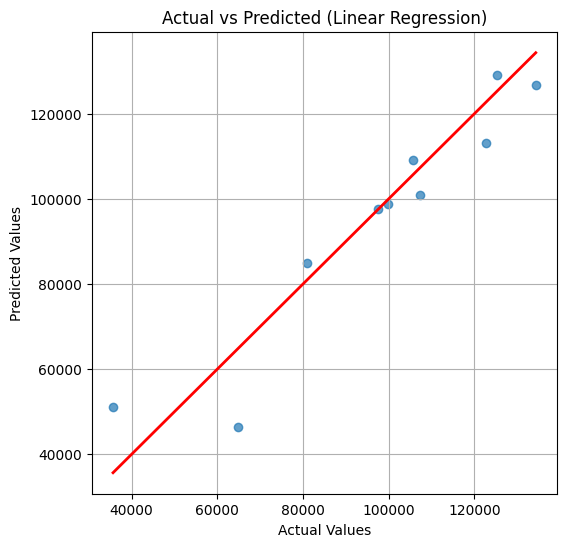

In [24]:
# Prediction Vs Actual

y_pred = model.predict(X_test)

plt.figure(figsize=(6,6))

# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Linear Regression)")
plt.grid(True)
plt.show()